1. Cargar datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

columnas = ['id', 'diagnosis'] + \
           [f'{stat}_{i}' for stat in ['mean','se','worst']
            for i in ['radius','texture','perimeter','area',
                      'smoothness','compactness','concavity',
                      'concave_points','symmetry','fractal_dim']]

df = pd.read_csv('data/wdbc.data', names=columnas)
df.drop(columns=['id'], inplace=True)

print("✅ Dataset cargado")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

✅ Dataset cargado
Filas: 569, Columnas: 31


2. Vista general

In [2]:
print("=== PRIMERAS FILAS ===")
display(df.head())

print("\n=== TIPOS DE VARIABLES ===")
print(df.dtypes)

numericas   = df.select_dtypes(include='number').columns.tolist()
print(f"\nNuméricas: {len(numericas)}")
print(f"Categóricas: diagnosis")

=== PRIMERAS FILAS ===


,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dim
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



=== TIPOS DE VARIABLES ===
diagnosis                   str
mean_radius             float64
mean_texture            float64
mean_perimeter          float64
mean_area               float64
mean_smoothness         float64
mean_compactness        float64
mean_concavity          float64
mean_concave_points     float64
mean_symmetry           float64
mean_fractal_dim        float64
se_radius               float64
se_texture              float64
se_perimeter            float64
se_area                 float64
se_smoothness           float64
se_compactness          float64
se_concavity            float64
se_concave_points       float64
se_symmetry             float64
se_fractal_dim          float64
worst_radius            float64
worst_texture           float64
worst_perimeter         float64
worst_area              float64
worst_smoothness        float64
worst_compactness       float64
worst_concavity         float64
worst_concave_points    float64
worst_symmetry          float64
worst_fracta

3. Valores nulos

In [3]:
nulos = df.isnull().sum()
porcentaje = (nulos / len(df) * 100).round(2)

missing = pd.DataFrame({
    'Valores nulos': nulos,
    'Porcentaje (%)': porcentaje
}).sort_values('Porcentaje (%)', ascending=False)

print("=== VALORES NULOS ===")
total = df.isnull().sum().sum()
print(f"Total nulos: {total}")
if total == 0:
    print("✅ No hay valores nulos")

=== VALORES NULOS ===
Total nulos: 0
✅ No hay valores nulos


4. Estadísticas descriptivas

In [4]:
df.describe().round(2)

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dim,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dim
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,16.27,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,4.83,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,7.93,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,13.01,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,14.97,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,18.79,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,36.04,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21


5. Distribución del diagnóstico

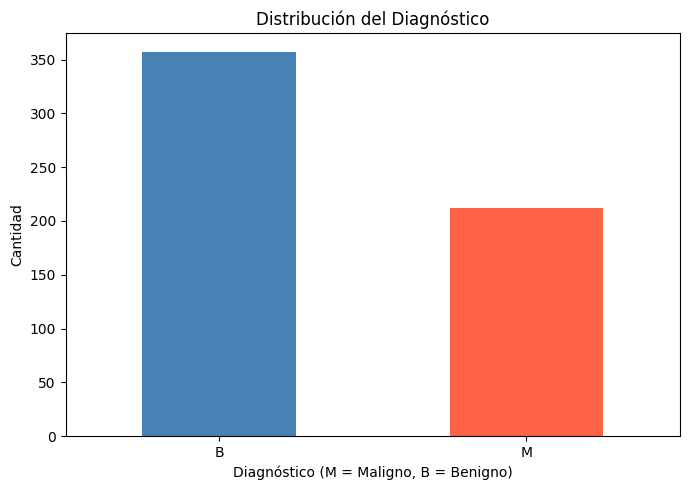

In [5]:
plt.figure(figsize=(7, 5))
colores = ['steelblue', 'tomato']
df['diagnosis'].value_counts().plot(kind='bar', color=colores)
plt.title('Distribución del Diagnóstico')
plt.xlabel('Diagnóstico (M = Maligno, B = Benigno)')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

6. Boxplots: variables mean por diagnóstico

C:\Users\Natalia\AppData\Local\Temp\ipykernel_13816\1393503074.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=col,
C:\Users\Natalia\AppData\Local\Temp\ipykernel_13816\1393503074.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=col,
C:\Users\Natalia\AppData\Local\Temp\ipykernel_13816\1393503074.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=col,
C:\Users\Natalia\AppData\Local\Temp\ipykernel_13816\1393503074.py:7: FutureWarning: 

Passing `palette` witho

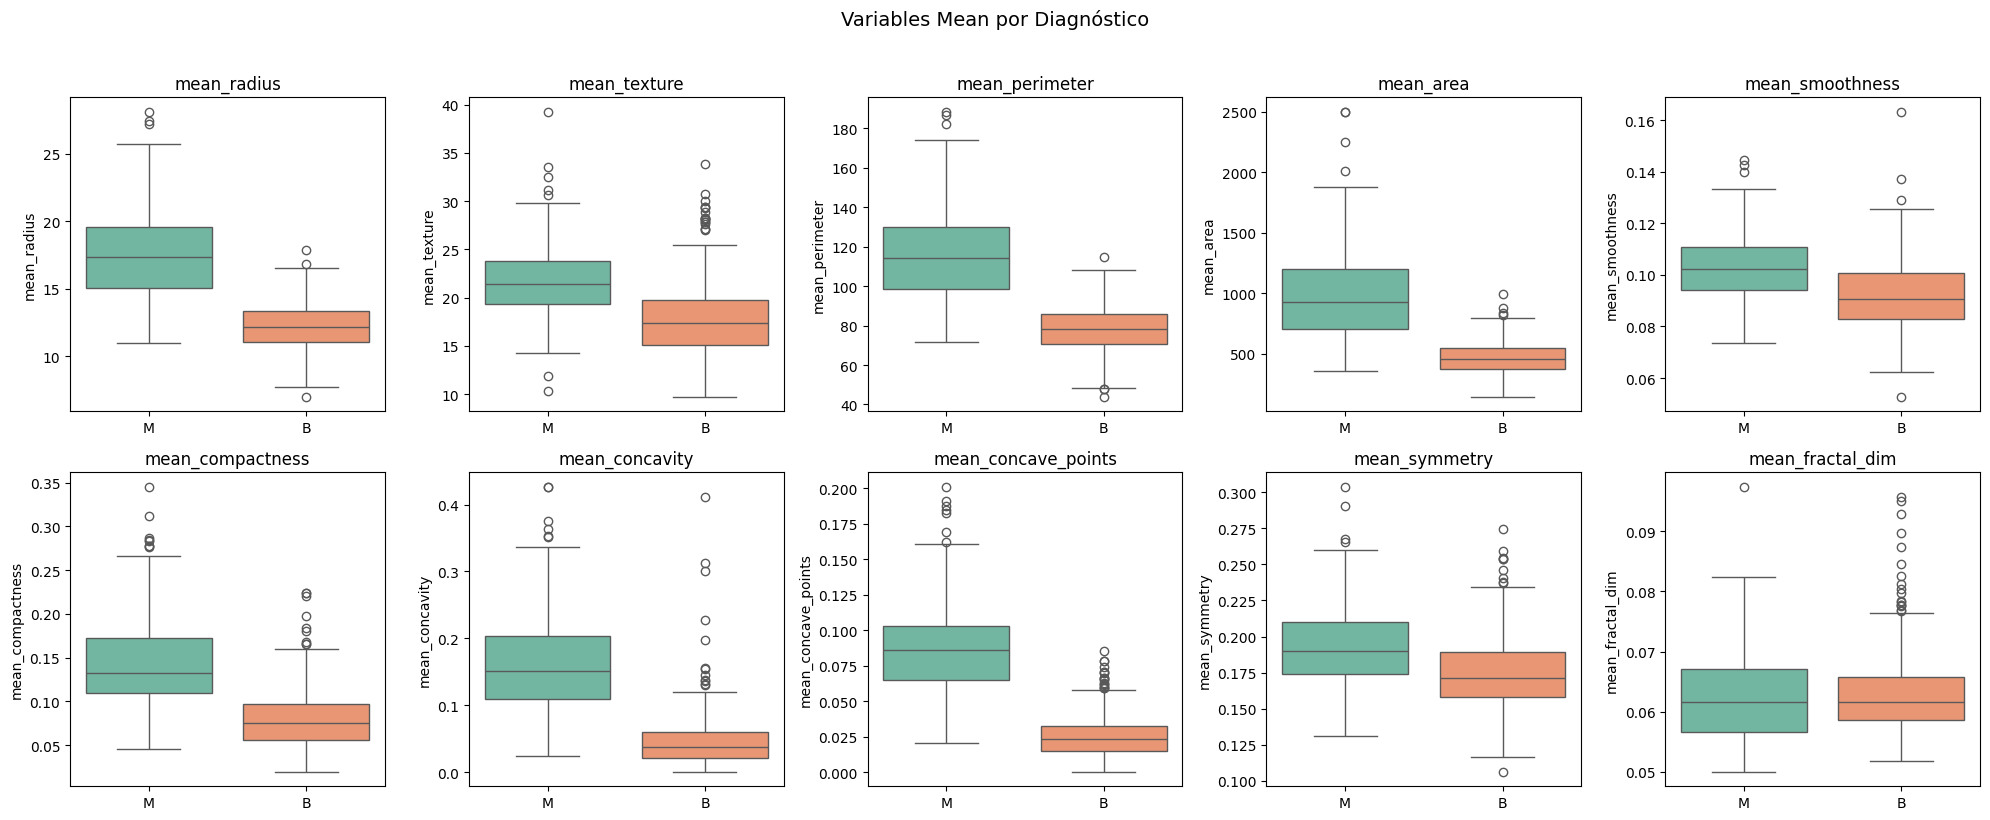

In [6]:
cols_mean = [c for c in df.columns if c.startswith('mean_')]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(cols_mean):
    sns.boxplot(data=df, x='diagnosis', y=col,
                palette='Set2', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Variables Mean por Diagnóstico', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

7. Correlaciones (solo variables mean)

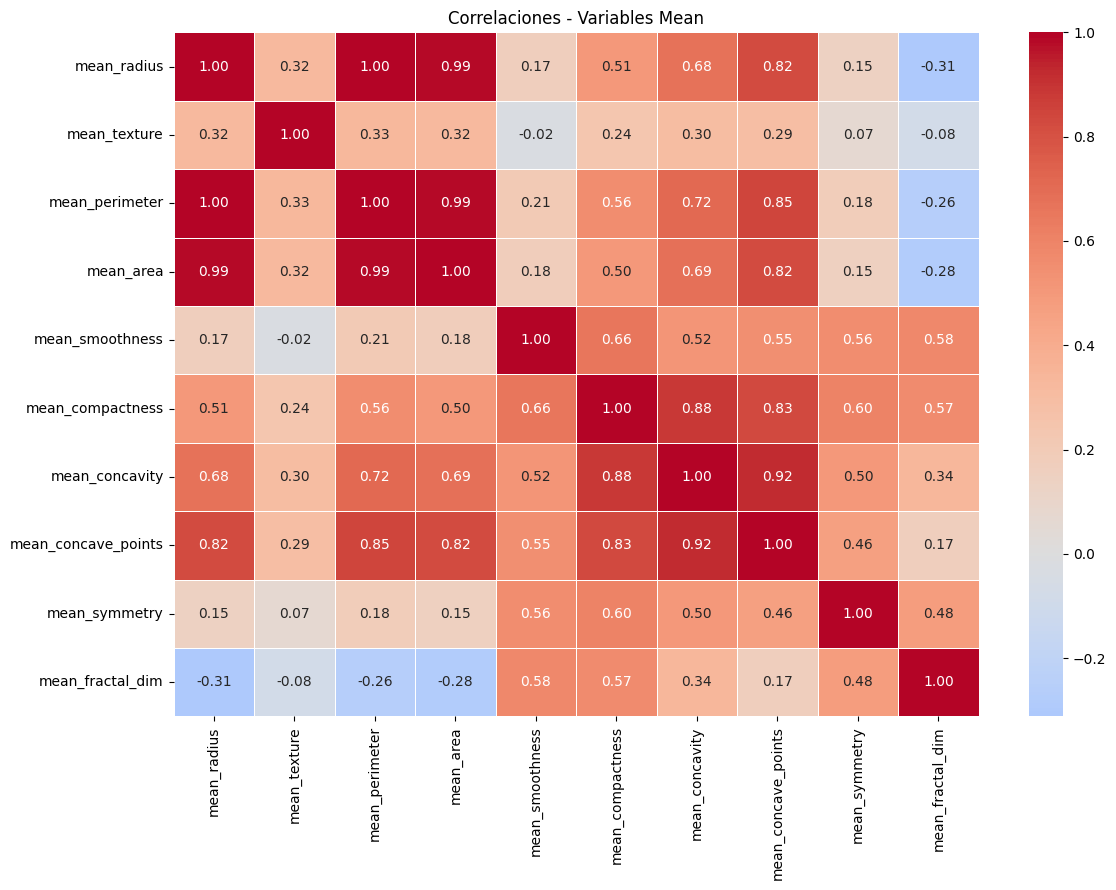

In [7]:
plt.figure(figsize=(12, 9))
corr = df[cols_mean].corr()
sns.heatmap(corr, cmap='coolwarm', annot=True,
            fmt='.2f', linewidths=0.5, center=0)
plt.title('Correlaciones - Variables Mean')
plt.tight_layout()
plt.show()

8. Pairplot variables más relevantes

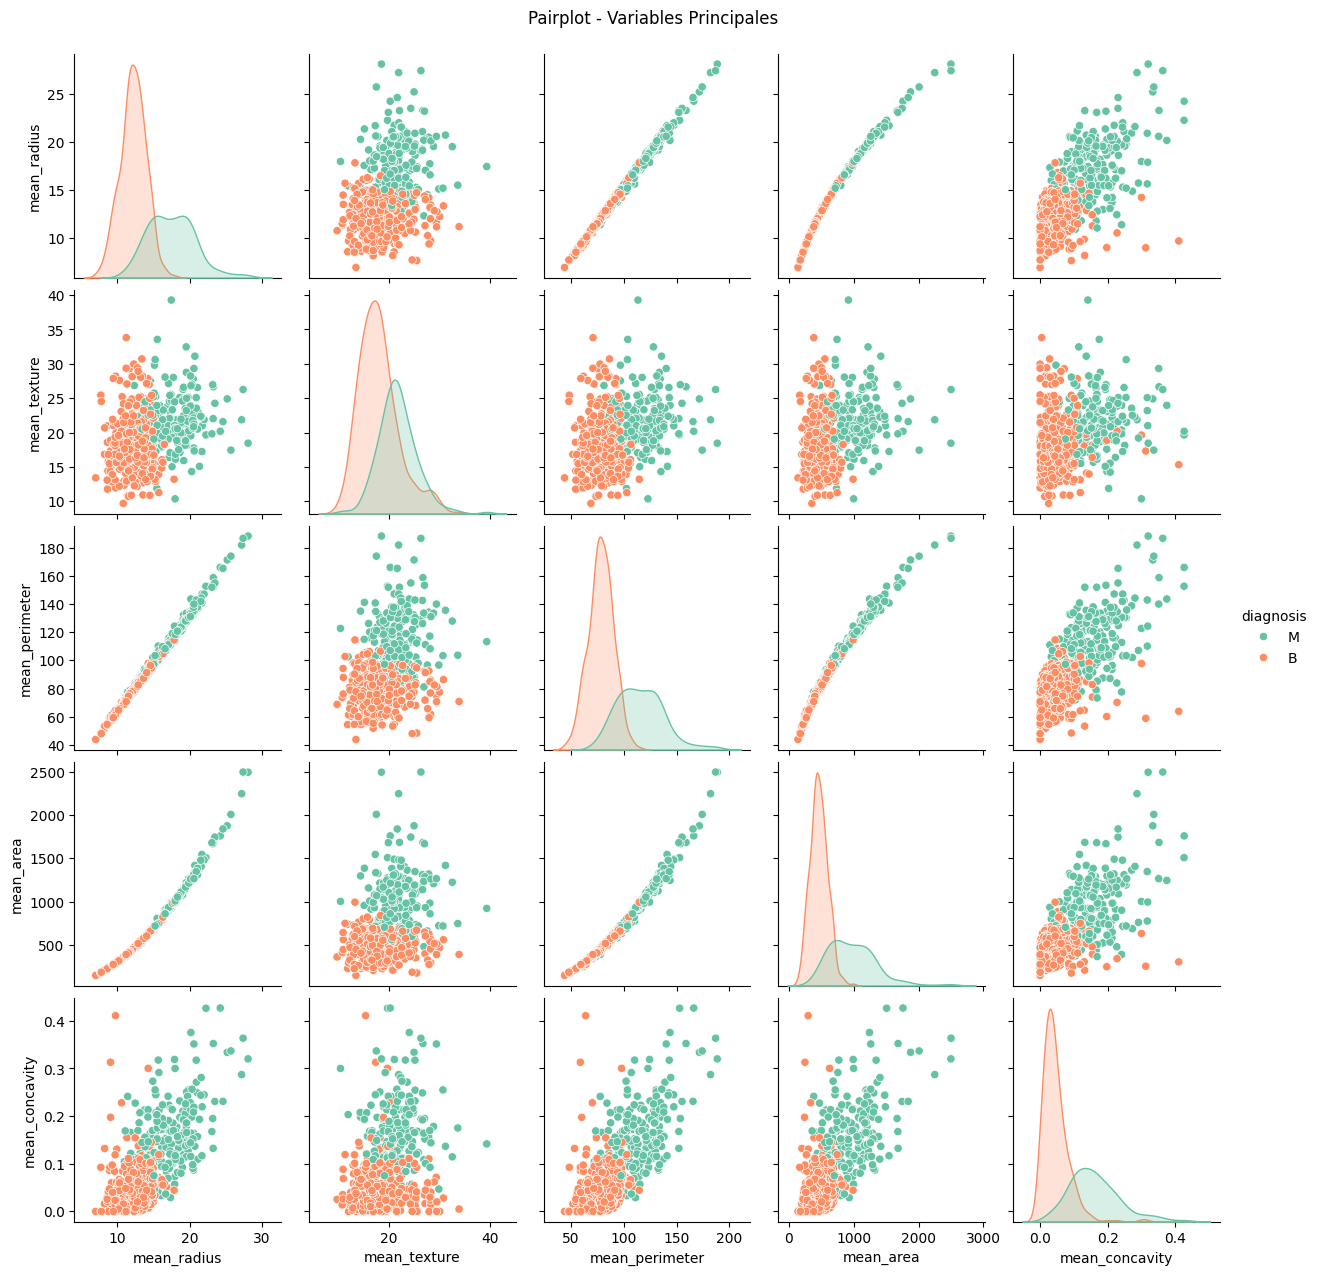

In [8]:
cols_select = ['mean_radius', 'mean_texture',
               'mean_perimeter', 'mean_area',
               'mean_concavity', 'diagnosis']

sns.pairplot(df[cols_select], hue='diagnosis',
             palette='Set2', diag_kind='kde')
plt.suptitle('Pairplot - Variables Principales', y=1.02)
plt.show()